# Classification histologique H&E
Members : Théo, Jehan, Stephan


Import of the libraries that will be used

In [1]:
# --- Imports et configuration (sans sklearn)
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

# --- Chemins principaux
CWD = os.getcwd()
if os.path.basename(CWD) == 'src':
    ROOT_DIR = os.path.abspath(os.path.join(CWD, '..'))
else:
    ROOT_DIR = CWD
DATA_DIR = os.path.join(ROOT_DIR, 'src', 'data')
TRAIN_CSV = os.path.join(DATA_DIR, 'train.csv')
TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'datasetjehan')
TEST_IMG_DIR = os.path.join(DATA_DIR, 'tdatasetJehan')
QUALITY_DIR = os.path.join(DATA_DIR, 'quality_control')
FEATURES_TRAIN_CSV = os.path.join(DATA_DIR, 'features_train.csv')
FIG_DIR = os.path.join(DATA_DIR, 'figures')

# --- Paramètres d'affichage
N_EXAMPLES_PER_CLASS = 5
RANDOM_STATE = 42

os.makedirs(FIG_DIR, exist_ok=True)

ModuleNotFoundError: No module named 'tqdm'

## Partie I — Exploration des données
**Ce que fait ce bloc :** charge le CSV, résume le dataset,
crée un dossier de contrôle qualité et affiche la distribution.

**Pourquoi ce choix :** l'exploration valide la cohérence
des labels et révèle un éventuel déséquilibre de classes.

**Alternative :** on pourrait échantillonner aléatoirement
sans copier les images, mais le dossier qualité accélère
les inspections manuelles ultérieures.

In [ ]:
# --- Chargement du CSV
train_df = pd.read_csv(TRAIN_CSV)

# --- Résumé global
num_samples = len(train_df)
label_names = sorted(train_df['Label'].unique())
label_counts = train_df['Label'].value_counts()

print(f'Total samples: {num_samples}')
print(f'Labels: {label_names}')

# --- Distribution des labels
plt.figure(figsize=(6, 4))
label_counts.plot(kind='bar')
plt.title('Distribution des labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'label_distribution.png'))
plt.show()

# --- Ratio de déséquilibre
imbalance_ratio = label_counts.max() / label_counts.min()
print(f'Imbalance ratio (max/min): {imbalance_ratio:.2f}')

# --- Dossier quality_control
os.makedirs(QUALITY_DIR, exist_ok=True)
for label in label_names:
    os.makedirs(os.path.join(QUALITY_DIR, str(label)),
                exist_ok=True)

# --- Copie d'images par label
def find_image_path(img_id, img_dir):
    """Retourne le chemin image existant pour un id."""
    exts = ['.png', '.jpg', '.jpeg']
    for ext in exts:
        cand = os.path.join(img_dir, f'{img_id}{ext}')
        if os.path.exists(cand):
            return cand
    return None

for _, row in train_df.iterrows():
    img_id = row['Image']
    label = row['Label']
    src_path = find_image_path(img_id, TRAIN_IMG_DIR)
    if src_path is None:
        continue
    dst_path = os.path.join(QUALITY_DIR, str(label),
                            os.path.basename(src_path))
    if not os.path.exists(dst_path):
        shutil.copyfile(src_path, dst_path)

**Pourquoi créer un dossier quality_control :** il permet
de vérifier visuellement des images représentatives
par classe, d'identifier les erreurs d'étiquetage et
les artefacts (blur, tâche, coupe dégradée).

**Interprétation de la distribution :** un ratio max/min
élevé suggère un déséquilibre, d'où l'usage de
`class_weight='balanced'` lors de l'entraînement.

**Outliers :** on ne retire pas d'images a priori afin
d'éviter d'introduire un biais manuel sans annotation
experte claire.

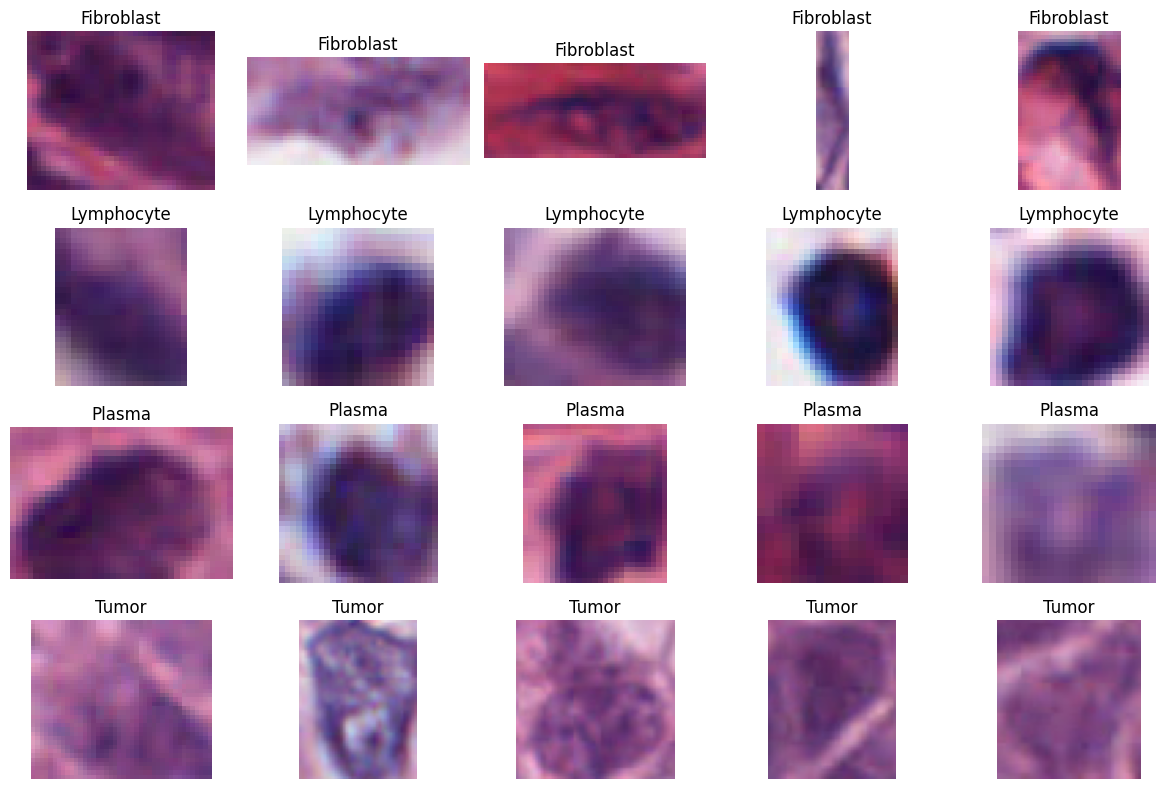

In [32]:
# --- Grille d'exemples par classe
np.random.seed(RANDOM_STATE)
fig, axes = plt.subplots(len(label_names),
                         N_EXAMPLES_PER_CLASS,
                         figsize=(12, 2 * len(label_names)))

for i, label in enumerate(label_names):
    subset = train_df[train_df['Label'] == label]
    sample_rows = subset.sample(
        n=min(N_EXAMPLES_PER_CLASS, len(subset)),
        random_state=RANDOM_STATE
    )
    for j, (_, row) in enumerate(sample_rows.iterrows()):
        img_path = find_image_path(row['Image'],
                                  TRAIN_IMG_DIR)
        ax = axes[i, j] if len(label_names) > 1 else axes[j]
        ax.axis('off')
        if img_path is None:
            ax.set_title('Missing')
            continue
        img = Image.open(img_path).convert('RGB')
        ax.imshow(img)
        ax.set_title(str(label))

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'examples_grid.png'))
plt.show()

**Observations visuelles (a completer) :**
- Couleurs dominantes par classe (H&E).
- Texture (granularite, homogénéité).
- Forme/organisation (amas, structures).
- Remarques sur d'eventuels artefacts.

## Partie II — Extraction de features (manuelle)
**Ce que fait ce bloc :** définit les fonctions de
prétraitement et le seuillage d'Otsu.

**Pourquoi ce choix :** Otsu s'adapte aux variations
d'exposition et ne nécessite pas de seuil fixe réglé
manuellement.

**Alternative :** un seuil fixe est plus simple mais
moins robuste aux variations d'éclairage.

In [33]:
# --- Préprocessing
def load_image_array(path):
    """Charge une image RGB et retourne un array uint8."""
    img = Image.open(path).convert('RGB')
    return np.asarray(img, dtype=np.uint8)


def to_grayscale(img_arr):
    """Gris ITU-R BT.601: 0.299R+0.587G+0.114B."""
    r = img_arr[..., 0].astype(np.float32)
    g = img_arr[..., 1].astype(np.float32)
    b = img_arr[..., 2].astype(np.float32)
    gray = 0.299 * r + 0.587 * g + 0.114 * b
    return gray.astype(np.float32)


def otsu_threshold(gray):
    """Masque booléen par seuillage d'Otsu."""
    hist, bin_edges = np.histogram(gray, bins=256,
                                  range=(0, 255))
    hist = hist.astype(np.float64)
    total = gray.size
    sum_total = np.dot(hist, np.arange(256))
    sum_b = 0.0
    w_b = 0.0
    max_var = -1.0
    threshold = 0

    for t in range(256):
        w_b += hist[t]
        if w_b == 0:
            continue
        w_f = total - w_b
        if w_f == 0:
            break
        sum_b += t * hist[t]
        m_b = sum_b / w_b
        m_f = (sum_total - sum_b) / w_f
        var_between = w_b * w_f * (m_b - m_f) ** 2
        if var_between > max_var:
            max_var = var_between
            threshold = t

    return gray >= threshold

**Ce que fait ce bloc :** définit les features d'aire,
de forme, d'intensité et de texture.

**Pourquoi ce choix :** la coloration H&E induit des
variations de teinte et de texture liées à la
morphologie cellulaire (noyaux vs cytoplasme).

**Alternative :** des features de Haralick seraient
pertinentes mais nécessitent des librairies externes.

In [34]:
# --- Features d'aire
def area_features(mask):
    """Features d'aire: ratio de pixels du masque."""
    area = np.sum(mask)
    area_ratio = area / mask.size
    return {
        'area_ratio': float(area_ratio)
    }


# --- Features de forme
def shape_features(mask):
    """Forme: centroide, ratio, compacite, radial std."""
    coords = np.column_stack(np.where(mask))
    if coords.size == 0:
        return {
            'centroid_x': 0.0,
            'centroid_y': 0.0,
            'aspect_ratio': 0.0,
            'compactness': 0.0,
            'std_radial': 0.0
        }

    h, w = mask.shape
    centroid_y, centroid_x = coords.mean(axis=0)
    centroid_x /= max(w - 1, 1)
    centroid_y /= max(h - 1, 1)

    min_y, min_x = coords.min(axis=0)
    max_y, max_x = coords.max(axis=0)
    bb_h = max(max_y - min_y + 1, 1)
    bb_w = max(max_x - min_x + 1, 1)
    aspect_ratio = bb_h / bb_w

    # Perimetre approx: pixels de bord
    mask_int = mask.astype(np.uint8)
    up = np.pad(mask_int[:-1, :], ((1, 0), (0, 0)))
    down = np.pad(mask_int[1:, :], ((0, 1), (0, 0)))
    left = np.pad(mask_int[:, :-1], ((0, 0), (1, 0)))
    right = np.pad(mask_int[:, 1:], ((0, 0), (0, 1)))
    edge = (mask_int == 1) & (
        (up == 0) | (down == 0) | (left == 0) | (right == 0)
    )
    perimeter = np.sum(edge)
    area = np.sum(mask_int)
    compactness = 0.0
    if perimeter > 0:
        compactness = 4.0 * np.pi * area / (perimeter ** 2)

    # Distances radiales
    cy = coords[:, 0].astype(np.float32)
    cx = coords[:, 1].astype(np.float32)
    center_y = coords[:, 0].mean()
    center_x = coords[:, 1].mean()
    radial = np.sqrt((cy - center_y) ** 2 +
                     (cx - center_x) ** 2)
    std_radial = float(np.std(radial))

    return {
        'centroid_x': float(centroid_x),
        'centroid_y': float(centroid_y),
        'aspect_ratio': float(aspect_ratio),
        'compactness': float(compactness),
        'std_radial': float(std_radial)
    }


def local_variance_3x3(gray):
    """Variance locale 3x3 sur une image float."""
    padded = np.pad(gray, ((1, 1), (1, 1)), mode='edge')
    sum_ = (
        padded[:-2, :-2] + padded[:-2, 1:-1] +
        padded[:-2, 2:] + padded[1:-1, :-2] +
        padded[1:-1, 1:-1] + padded[1:-1, 2:] +
        padded[2:, :-2] + padded[2:, 1:-1] +
        padded[2:, 2:]
    )
    mean_ = sum_ / 9.0
    sq_sum = (
        padded[:-2, :-2] ** 2 + padded[:-2, 1:-1] ** 2 +
        padded[:-2, 2:] ** 2 + padded[1:-1, :-2] ** 2 +
        padded[1:-1, 1:-1] ** 2 + padded[1:-1, 2:] ** 2 +
        padded[2:, :-2] ** 2 + padded[2:, 1:-1] ** 2 +
        padded[2:, 2:] ** 2
    )
    mean_sq = sq_sum / 9.0
    var_ = np.maximum(mean_sq - mean_ ** 2, 0.0)
    return var_


# --- Features d'intensite
def intensity_features(img_arr, gray):
    """Stats de niveaux de gris et couleurs H&E."""
    gray_flat = gray.reshape(-1)
    p25, p50, p75 = np.percentile(gray_flat, [25, 50, 75])

    r = img_arr[..., 0].astype(np.float32)
    g = img_arr[..., 1].astype(np.float32)
    b = img_arr[..., 2].astype(np.float32)

    hue_ratio = np.mean(g / (r + b + 1e-6))
    local_var = local_variance_3x3(gray)

    return {
        'gray_mean': float(np.mean(gray_flat)),
        'gray_std': float(np.std(gray_flat)),
        'gray_p25': float(p25),
        'gray_p50': float(p50),
        'gray_p75': float(p75),
        'r_mean': float(np.mean(r)),
        'r_std': float(np.std(r)),
        'g_mean': float(np.mean(g)),
        'g_std': float(np.std(g)),
        'b_mean': float(np.mean(b)),
        'b_std': float(np.std(b)),
        'hue_ratio': float(hue_ratio),
        'texture_mean_var': float(np.mean(local_var)),
        'texture_std_var': float(np.std(local_var))
    }

**Justification des features :**
- `area_ratio` : proportion de tissu vs fond.
- `compactness` / `aspect_ratio` : morphologie.
- `std_radial` : irregularite des contours.
- `gray_*` : densite globale en H&E.
- `r/g/b_mean` : balance noyaux (bleu) vs
  cytoplasme (rose).
- `hue_ratio` : contraste vert par rapport a R+B,
  utile pour distinguer teintes proches.
- `texture_*` : heterogeneite locale des motifs.

**Ce que fait ce bloc :** crée la fonction d'extraction
complète et lance l'extraction sur tout le train set.

**Pourquoi ce choix :** un pipeline unique garantit que
train et test utilisent les mêmes transformations.

**Alternative :** pré-calculer les masques et les stocker,
mais cela augmente l'espace disque.

In [35]:
# --- Pipeline complet d'extraction
def extract_all_features(img_path):
    """Extrait toutes les features pour une image."""
    img_arr = load_image_array(img_path)
    gray = to_grayscale(img_arr)
    mask = otsu_threshold(gray)

    features = {}
    features.update(area_features(mask))
    features.update(shape_features(mask))
    features.update(intensity_features(img_arr, gray))
    return features


# --- Extraction sur le train set
all_rows = []
for _, row in tqdm(train_df.iterrows(), total=len(train_df)):
    img_id = row['Image']
    label = row['Label']
    img_path = find_image_path(img_id, TRAIN_IMG_DIR)
    if img_path is None:
        continue
    try:
        feats = extract_all_features(img_path)
        feats['Image'] = img_id
        feats['Label'] = label
        all_rows.append(feats)
    except Exception:
        continue

features_df = pd.DataFrame(all_rows)
features_df.to_csv(FEATURES_TRAIN_CSV, index=False)
print(f'Saved: {FEATURES_TRAIN_CSV}')

100%|██████████| 400/400 [00:01<00:00, 274.31it/s]

Saved: c:\Users\vince\Documents\renducode\renduIAOp\cell_classification\src\data\features_train.csv


**Ce que fait ce bloc :** visualise les distributions
des features et la corrélation entre elles.

**Pourquoi ce choix :** les boxplots permettent
d'identifier des features discriminantes, tandis que
la corrélation révèle les redondances.

**Alternative :** une PCA serait possible, mais elle
masque l'interprétation biologique des features.

C:\Users\vince\AppData\Local\Temp\ipykernel_75516\2656509449.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(l) for l in label_names])


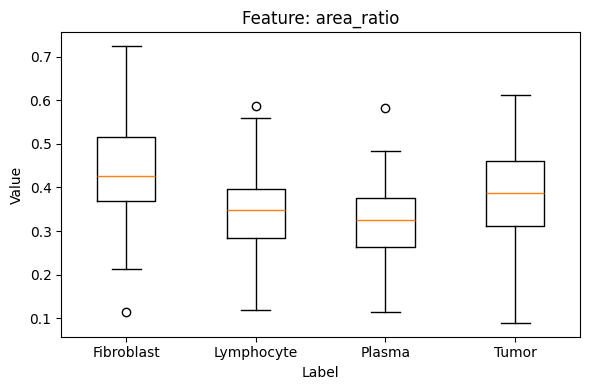

C:\Users\vince\AppData\Local\Temp\ipykernel_75516\2656509449.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(l) for l in label_names])


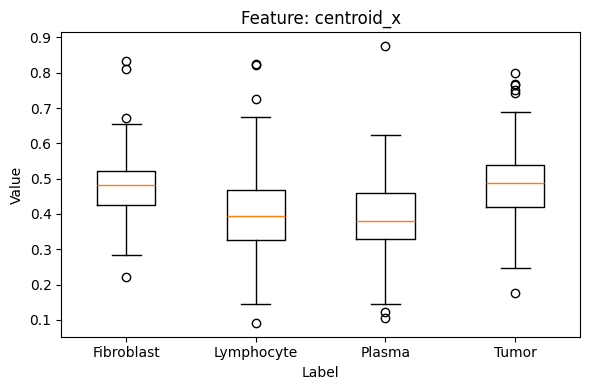

C:\Users\vince\AppData\Local\Temp\ipykernel_75516\2656509449.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(l) for l in label_names])


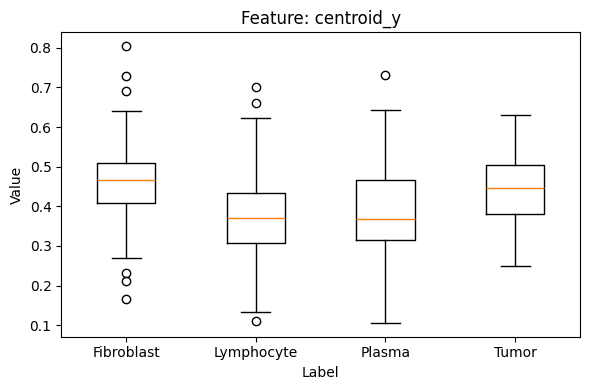

C:\Users\vince\AppData\Local\Temp\ipykernel_75516\2656509449.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(l) for l in label_names])


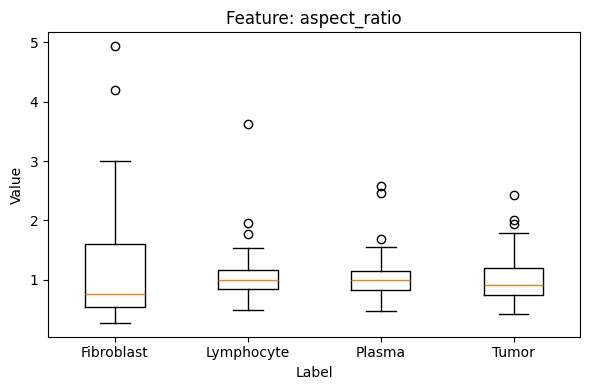

C:\Users\vince\AppData\Local\Temp\ipykernel_75516\2656509449.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(l) for l in label_names])


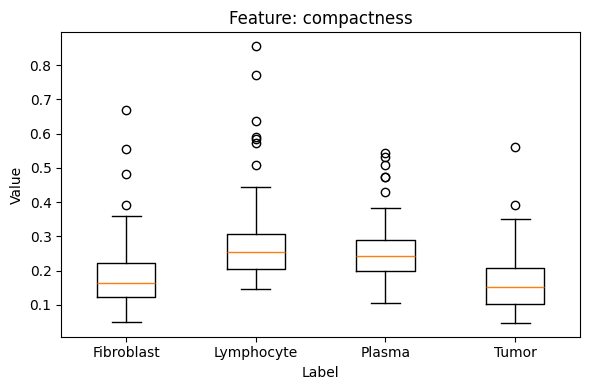

C:\Users\vince\AppData\Local\Temp\ipykernel_75516\2656509449.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(l) for l in label_names])


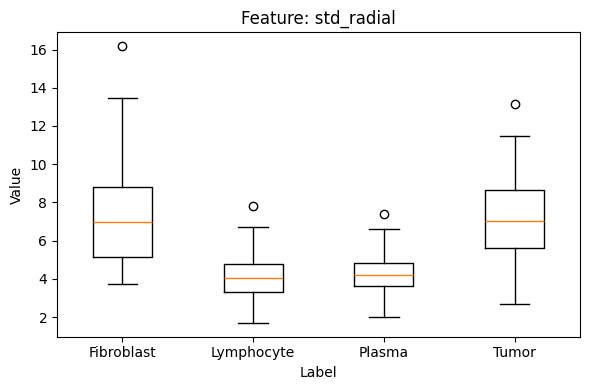

C:\Users\vince\AppData\Local\Temp\ipykernel_75516\2656509449.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(l) for l in label_names])


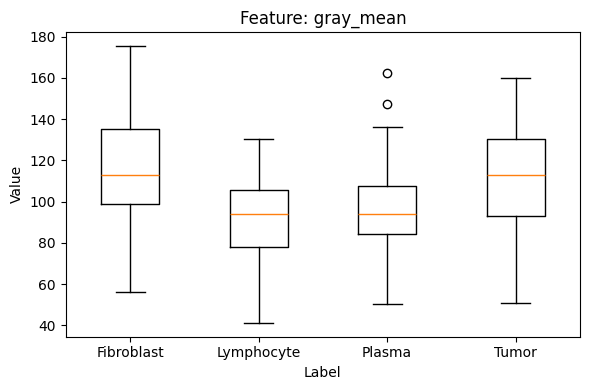

C:\Users\vince\AppData\Local\Temp\ipykernel_75516\2656509449.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(l) for l in label_names])


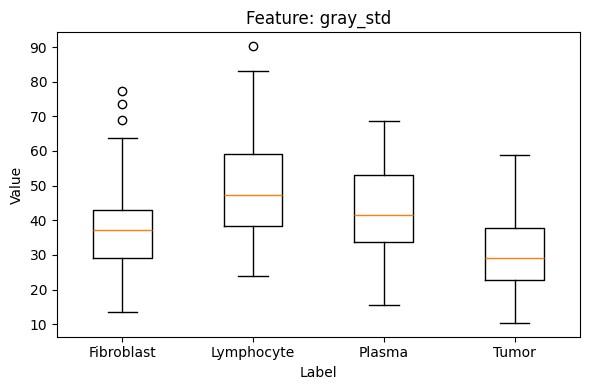

C:\Users\vince\AppData\Local\Temp\ipykernel_75516\2656509449.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(l) for l in label_names])


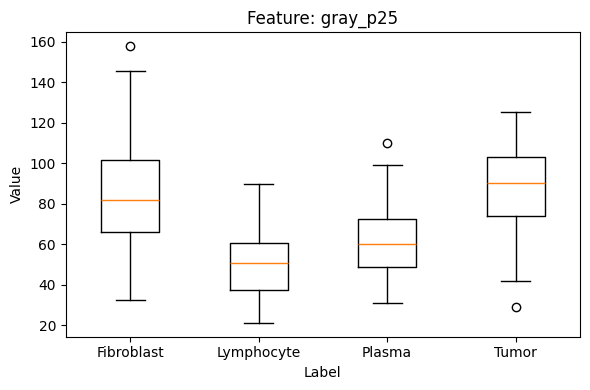

C:\Users\vince\AppData\Local\Temp\ipykernel_75516\2656509449.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(l) for l in label_names])


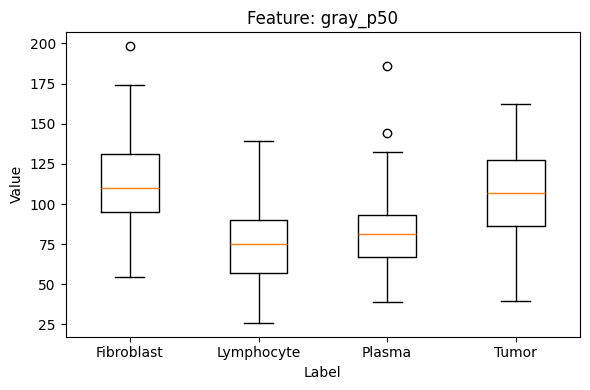

C:\Users\vince\AppData\Local\Temp\ipykernel_75516\2656509449.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(l) for l in label_names])


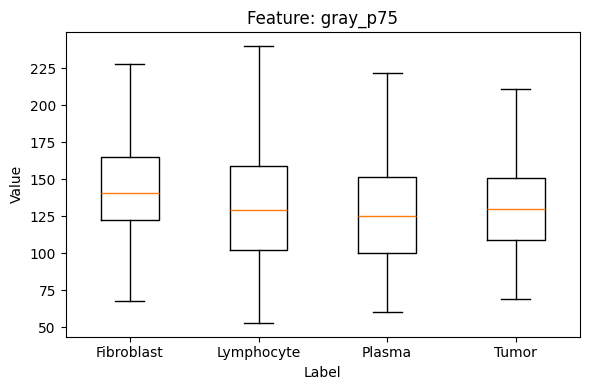

C:\Users\vince\AppData\Local\Temp\ipykernel_75516\2656509449.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(l) for l in label_names])


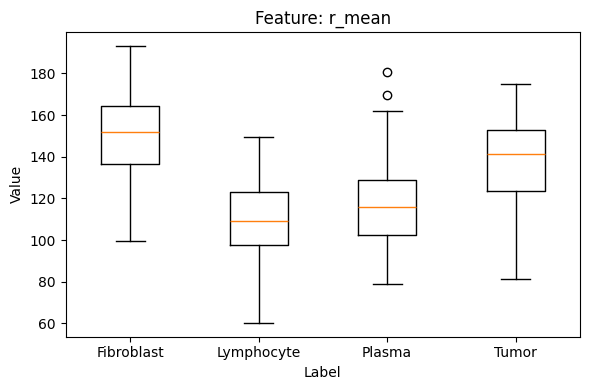

C:\Users\vince\AppData\Local\Temp\ipykernel_75516\2656509449.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(l) for l in label_names])


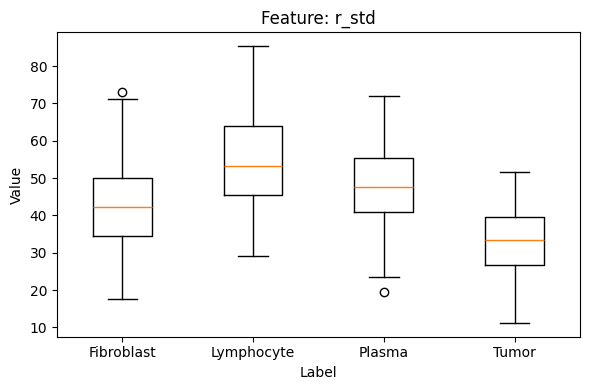

C:\Users\vince\AppData\Local\Temp\ipykernel_75516\2656509449.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(l) for l in label_names])


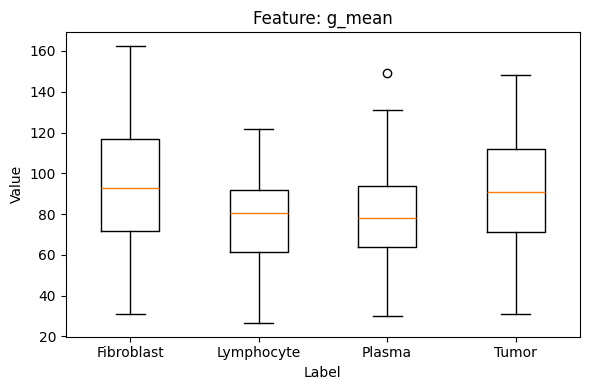

C:\Users\vince\AppData\Local\Temp\ipykernel_75516\2656509449.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(l) for l in label_names])


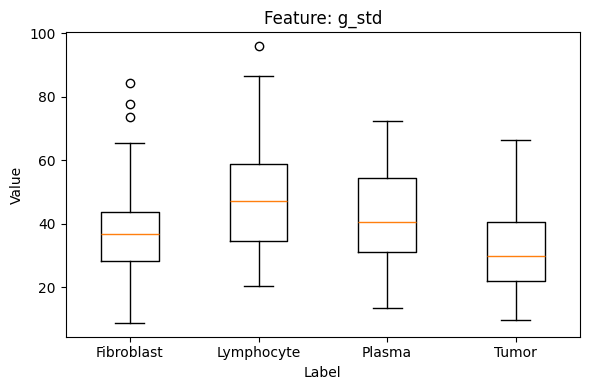

C:\Users\vince\AppData\Local\Temp\ipykernel_75516\2656509449.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(l) for l in label_names])


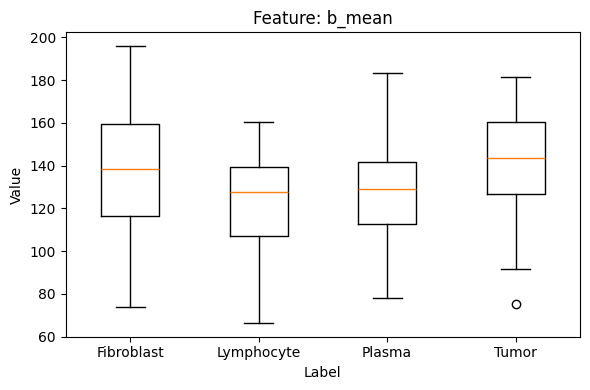

C:\Users\vince\AppData\Local\Temp\ipykernel_75516\2656509449.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(l) for l in label_names])


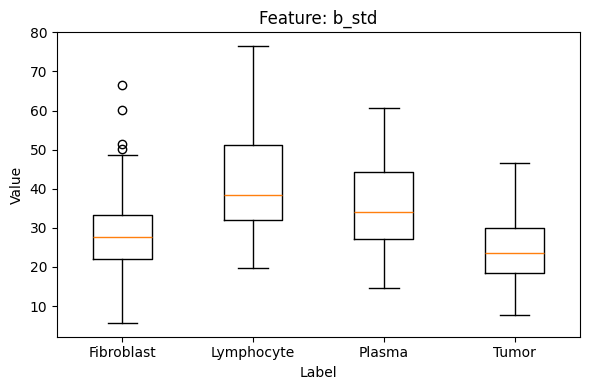

C:\Users\vince\AppData\Local\Temp\ipykernel_75516\2656509449.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(l) for l in label_names])


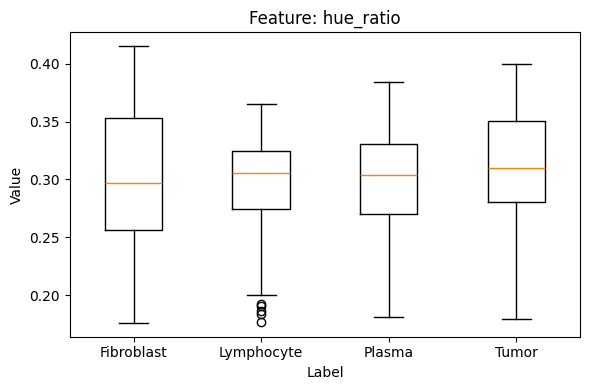

C:\Users\vince\AppData\Local\Temp\ipykernel_75516\2656509449.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(l) for l in label_names])


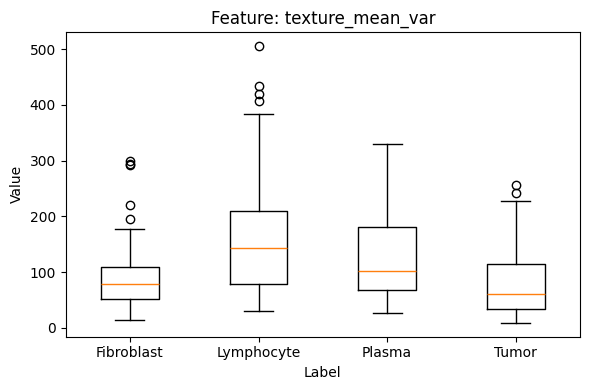

C:\Users\vince\AppData\Local\Temp\ipykernel_75516\2656509449.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(l) for l in label_names])


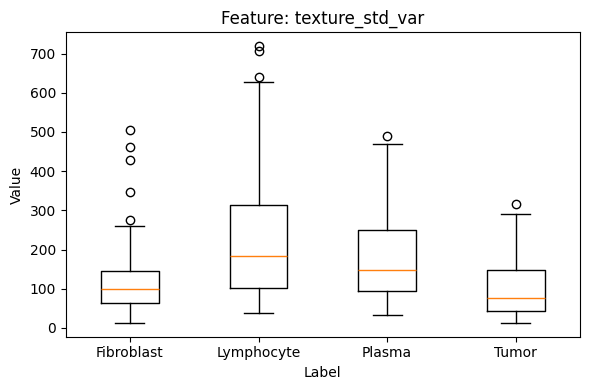

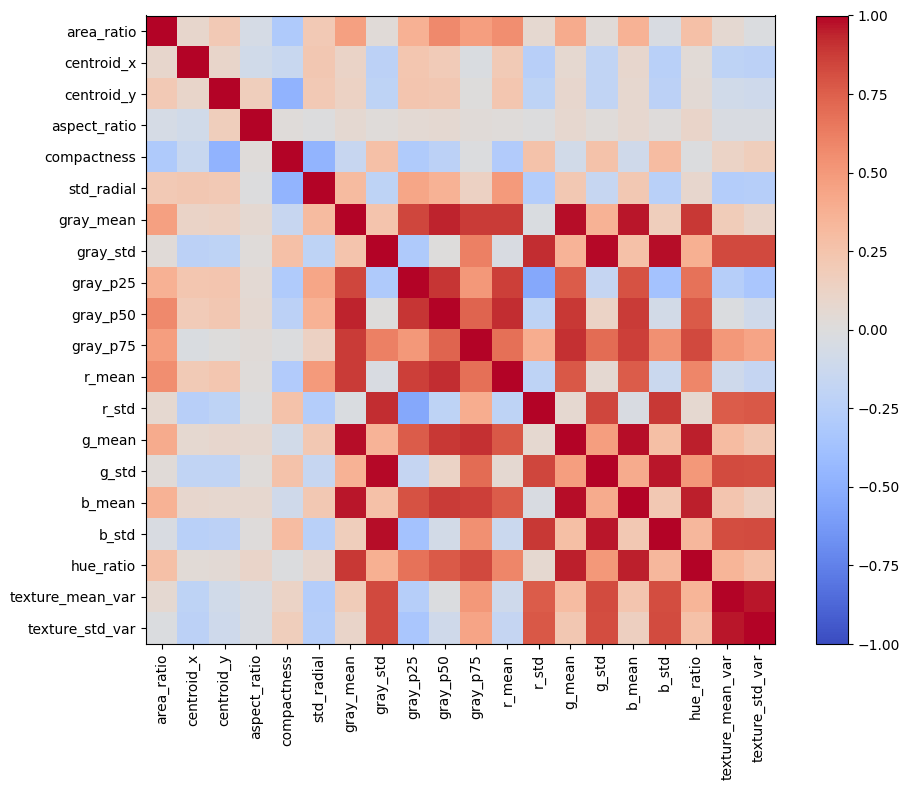

High correlations (|r| > 0.9):
gray_mean gray_p50 0.94
gray_mean g_mean 0.98
gray_mean b_mean 0.97
gray_std r_std 0.92
gray_std g_std 0.99
gray_std b_std 0.98
gray_p50 r_mean 0.92
gray_p75 g_mean 0.91
g_mean b_mean 0.98
g_mean hue_ratio 0.95
g_std b_std 0.96
b_mean hue_ratio 0.95
texture_mean_var texture_std_var 0.97


In [36]:
# --- Boxplots par classe (1 figure par feature)
viz_df = features_df.copy()
feature_cols = [c for c in viz_df.columns
                if c not in ['Image', 'Label']]

for feat in feature_cols:
    plt.figure(figsize=(6, 4))
    data = [
        viz_df[viz_df['Label'] == lab][feat].values
        for lab in label_names
    ]
    plt.boxplot(data, labels=[str(l) for l in label_names])
    plt.title(f'Feature: {feat}')
    plt.xlabel('Label')
    plt.ylabel('Value')
    plt.tight_layout()
    fname = f'box_{feat}.png'
    plt.savefig(os.path.join(FIG_DIR, fname))
    plt.show()

# --- Heatmap de corrélation
corr = viz_df[feature_cols].corr()
plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(feature_cols)), feature_cols,
           rotation=90)
plt.yticks(range(len(feature_cols)), feature_cols)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'features_corr.png'))
plt.show()

# --- Paires corrélées
high_corr = []
for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        val = corr.iloc[i, j]
        if abs(val) > 0.9:
            high_corr.append((feature_cols[i],
                              feature_cols[j],
                              float(val)))

print('High correlations (|r| > 0.9):')
for a, b, v in high_corr:
    print(a, b, f'{v:.2f}')

**Analyse (a completer) :**
- Features les plus separatrices selon les boxplots.
- Paires tres corrélées a supprimer (|r| > 0.9).
- Features peu informatives a exclure si besoin.

## Partie III — Entraînement ML
**Ce que fait ce bloc :** prépare les données et
définit le pipeline de sélection et normalisation.

**Pourquoi ce choix :** le SVM est sensible à l'échelle,
d'où l'utilisation de `StandardScaler`.

**Alternative :** MinMaxScaler serait possible, mais
StandardScaler est robuste aux distributions non bornées.

In [37]:
# --- Imports sklearn
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# --- Chargement des features
ml_df = pd.read_csv(FEATURES_TRAIN_CSV)
ml_df = ml_df.dropna()

feature_cols = [c for c in ml_df.columns
                if c not in ['Image', 'Label']]

# --- Suppression des features trop corrélées
corr = ml_df[feature_cols].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1)
                   .astype(bool))
to_drop = [col for col in upper.columns
           if any(upper[col] > 0.95)]

selected_features = [c for c in feature_cols
                     if c not in to_drop]

X = ml_df[selected_features].values
y = ml_df['Label'].values

**SVM (RBF) :** bon pour petits datasets et frontières
non linéaires. `class_weight='balanced'` compense
le déséquilibre observé.

**Hyperparamètres :** C contrôle la marge, gamma
contrôle la complexité du noyau.

In [38]:
from sklearn.svm import SVC

skf = StratifiedKFold(n_splits=5, shuffle=True,
                      random_state=RANDOM_STATE)

svm_pipeline = Pipeline([
    ('select', SelectKBest(score_func=f_classif,
                           k='all')),
    ('scale', StandardScaler()),
    ('clf', SVC(kernel='rbf', class_weight='balanced'))
])

svm_params = {
    'clf__C': [0.1, 1, 10, 100],
    'clf__gamma': ['scale', 0.01, 0.1]
}

svm_search = GridSearchCV(
    svm_pipeline, svm_params, cv=skf, scoring='f1_weighted'
)
svm_search.fit(X, y)
best_svm = svm_search.best_estimator_
print('Best SVM:', svm_search.best_params_)

Best SVM: {'clf__C': 10, 'clf__gamma': 0.01}


**Random Forest :** robuste aux features redondantes
et fournit des importances de variables.

**Hyperparamètres :** n_estimators stabilise
les votes, max_depth limite le sur-apprentissage.

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('select', SelectKBest(score_func=f_classif,
                           k='all')),
    ('scale', StandardScaler()),
    ('clf', RandomForestClassifier(
        class_weight='balanced', random_state=RANDOM_STATE
    ))
])

rf_params = {
    'clf__n_estimators': [50, 100, 200],
    'clf__max_depth': [None, 5, 10, 20]
}

rf_search = GridSearchCV(
    rf_pipeline, rf_params, cv=skf, scoring='f1_weighted'
)
rf_search.fit(X, y)
best_rf = rf_search.best_estimator_
print('Best RF:', rf_search.best_params_)

Best RF: {'clf__max_depth': None, 'clf__n_estimators': 200}


**Ce que fait ce bloc :** compare les modèles,
affiche une matrice de confusion et sélectionne
le meilleur modèle.

**Pourquoi ce choix :** la validation croisée
stratifiée préserve la distribution des classes.

**Analyse attendue :** observer les confusions entre
classes proches en texture ou couleur.

          model  accuracy  f1_weighted
0           SVM  0.679487     0.680302
1  RandomForest  0.635897     0.636467


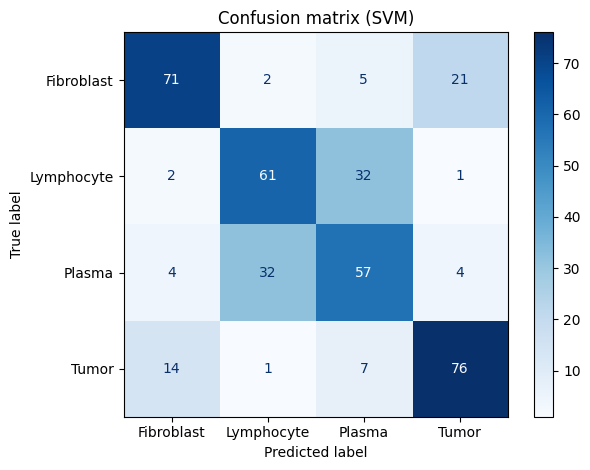

In [40]:
from sklearn.model_selection import cross_val_predict

models = {
    'SVM': best_svm,
    'RandomForest': best_rf
}

results = []
for name, model in models.items():
    preds = cross_val_predict(model, X, y, cv=skf)
    acc = accuracy_score(y, preds)
    f1 = f1_score(y, preds, average='weighted')
    results.append({'model': name,
                    'accuracy': acc,
                    'f1_weighted': f1})

results_df = pd.DataFrame(results)
print(results_df)

# --- Choix du meilleur modele
best_row = results_df.sort_values(
    'f1_weighted', ascending=False
).iloc[0]
best_name = best_row['model']
best_model = models[best_name]

# --- Matrice de confusion
best_preds = cross_val_predict(best_model, X, y, cv=skf)
cm = confusion_matrix(y, best_preds, labels=label_names)
disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
disp.plot(cmap='Blues')
plt.title(f'Confusion matrix ({best_name})')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'confusion_matrix.png'))
plt.show()

**Analyse des erreurs (a completer) :**
- Quelles classes sont le plus confondues ?
- Hypotheses biologiques (texture/couleur proches).
- Choix du meilleur modele et justification.

**Ce que fait ce bloc :** affiche l'importance des
features pour la Random Forest.

**Pourquoi ce choix :** aide à interpréter quelles
mesures sont les plus discriminantes biologiquement.

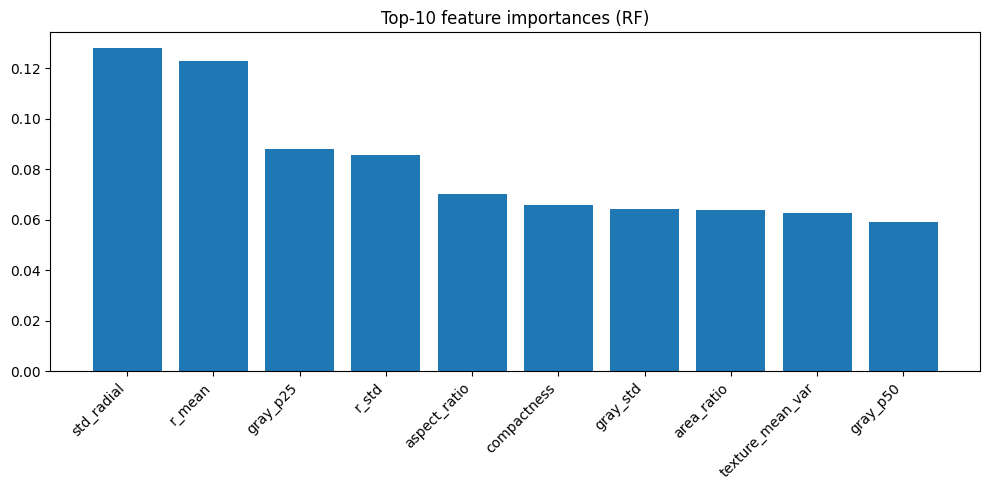

In [41]:
# --- Importance des features (Random Forest)
rf_clf = best_rf.named_steps['clf']
importances = rf_clf.feature_importances_

feat_imp = pd.DataFrame({
    'feature': selected_features,
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(feat_imp['feature'][:10],
        feat_imp['importance'][:10])
plt.xticks(rotation=45, ha='right')
plt.title('Top-10 feature importances (RF)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'rf_importances.png'))
plt.show()

## Partie IV — Prédiction sur le test set (optionnel)
**Ce que fait ce bloc :** extrait les features du test
et génère un CSV de prédictions.

**Pourquoi ce choix :** format identique à `train.csv`
pour une soumission directe.

In [42]:
def predict_test_set(test_img_dir, best_pipeline,
                     output_csv='test.csv'):
    """Predictions sur test set et sauvegarde CSV."""
    if not os.path.exists(test_img_dir):
        print('Test directory not found.')
        return None

    img_files = [
        f for f in os.listdir(test_img_dir)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]
    img_ids = [os.path.splitext(f)[0] for f in img_files]

    rows = []
    used_ids = []
    for img_id in tqdm(img_ids):
        img_path = find_image_path(img_id, test_img_dir)
        if img_path is None:
            continue
        try:
            feats = extract_all_features(img_path)
            rows.append(feats)
            used_ids.append(img_id)
        except Exception:
            continue

    test_features = pd.DataFrame(rows)
    for col in selected_features:
        if col not in test_features.columns:
            test_features[col] = 0.0
    test_features = test_features[selected_features]
    test_features = test_features.fillna(0.0)
    preds = best_pipeline.predict(test_features.values)

    out_df = pd.DataFrame({
        'image_id': used_ids,
        'label': preds
    })
    out_df.to_csv(output_csv, index=False)
    print(f'Saved: {output_csv}')
    return out_df

# --- Execution si le dossier test existe
if os.path.exists(TEST_IMG_DIR):
    _ = predict_test_set(
        TEST_IMG_DIR,
        best_model,
        output_csv=os.path.join(DATA_DIR, 'test.csv')
    )

100%|██████████| 400/400 [00:03<00:00, 117.03it/s]

Saved: c:\Users\vince\Documents\renducode\renduIAOp\cell_classification\src\data\test.csv
